In [1]:
# Run once
!pip install scikit-fuzzy numpy matplotlib scikit-learn tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 8.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
print("✓ All libraries imported")

✓ All libraries imported


In [3]:
np.random.seed(42)
N = 500

attendance   = np.random.randint(40, 100, N)
assignment   = np.random.randint(30, 100, N)
test_marks   = np.random.randint(25, 100, N)

# Label using weighted composite score
composite = 0.3 * attendance + 0.3 * assignment + 0.4 * test_marks

performance = np.where(composite < 52, 0,    # 0 = Poor
              np.where(composite < 68, 1, 2)) # 1 = Average, 2 = Good

X = np.column_stack([attendance, assignment, test_marks]).astype(float)
y = performance

labels = ['Poor', 'Average', 'Good']
for i, lbl in enumerate(labels):
    print(f"  {lbl}: {(y==i).sum()} samples")
print(f"✓ Dataset ready — {N} students")

  Poor: 75 samples
  Average: 213 samples
  Good: 212 samples
✓ Dataset ready — 500 students


In [4]:
# ── Universe of discourse ──────────────────────────────────────────
u = np.arange(0, 101, 1)

# ── Bell-shaped MF generator ───────────────────────────────────────
def gbellmf(x, a, b, c):
    """Generalised bell MF: 1 / (1 + |(x-c)/a|^2b)"""
    return 1.0 / (1.0 + np.abs((x - c) / (a + 1e-9)) ** (2 * b))

# ── Fuzzification function ─────────────────────────────────────────
def fuzzify(val):
    """Returns [μ_Poor, μ_Average, μ_Good] for a scalar 0-100."""
    return np.array([
        gbellmf(val, 25, 2, 20),  # Poor
        gbellmf(val, 25, 2, 55),  # Average
        gbellmf(val, 25, 2, 85),  # Good
    ])

# ── Build fuzzified feature matrix (9 features = 3 inputs × 3 MFs) ─
def build_fuzzy_features(X_raw):
    rows = []
    for att, asgn, tst in X_raw:
        mu_att  = fuzzify(att)
        mu_asgn = fuzzify(asgn)
        mu_tst  = fuzzify(tst)
        rows.append(np.concatenate([mu_att, mu_asgn, mu_tst]))
    return np.array(rows)

X_fuzzy = build_fuzzy_features(X)
print(f"✓ Fuzzified feature matrix: {X_fuzzy.shape}")
print("  Columns: [att_Poor, att_Avg, att_Good, asgn_Poor, ...]")

✓ Fuzzified feature matrix: (500, 9)
  Columns: [att_Poor, att_Avg, att_Good, asgn_Poor, ...]


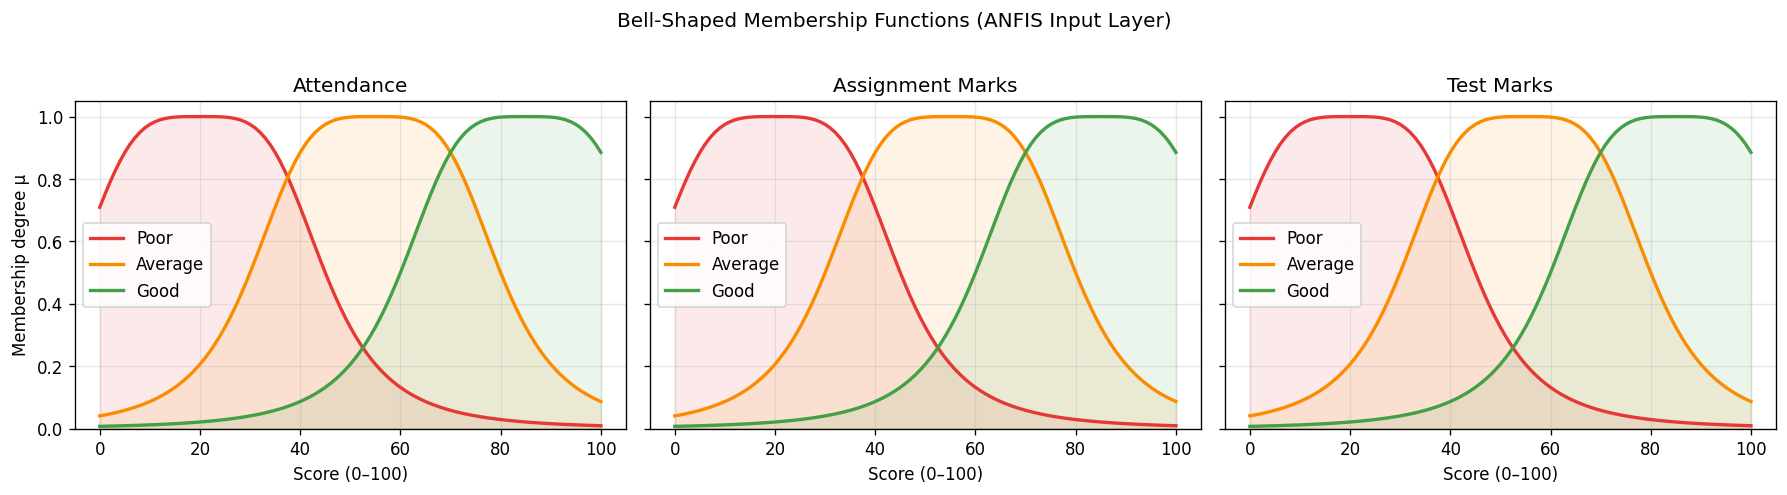

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ['#E53935', '#FB8C00', '#43A047']
titles = ['Attendance', 'Assignment Marks', 'Test Marks']

for ax, title in zip(axes, titles):
    for (label, center), col in zip(
            [('Poor',20),('Average',55),('Good',85)], colors):
        mf = gbellmf(u, 25, 2, center)
        ax.plot(u, mf, color=col, lw=2, label=label)
        ax.fill_between(u, mf, alpha=0.1, color=col)
    ax.set_title(title); ax.set_xlabel('Score (0–100)')
    ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)

axes[0].set_ylabel('Membership degree μ')
plt.suptitle('Bell-Shaped Membership Functions (ANFIS Input Layer)', y=1.02)
plt.tight_layout()
plt.savefig('student_mfs.png', bbox_inches='tight'); plt.show()

In [6]:
# ── 9 Takagi-Sugeno style rules (IF att AND asgn AND test THEN ...) ─
RULES = [
    ('Poor',   'Poor',    'Poor',    0, 1.00),
    ('Poor',   'Average', 'Poor',    0, 0.90),
    ('Average','Poor',    'Poor',    0, 0.85),
    ('Average','Average', 'Average', 1, 1.00),
    ('Poor',   'Good',    'Average', 1, 0.80),
    ('Good',   'Poor',    'Average', 1, 0.80),
    ('Average','Good',    'Average', 1, 0.85),
    ('Good',   'Average', 'Average', 2, 0.90),
    ('Good',   'Good',    'Good',    2, 1.00),
]
idx_map = {'Poor': 0, 'Average': 1, 'Good': 2}

def fuzzy_infer(att, asgn, tst):
    mu_a = fuzzify(att);  mu_s = fuzzify(asgn);  mu_t = fuzzify(tst)
    votes = np.zeros(3)
    for ra, rs, rt, out, w in RULES:
        strength = min(mu_a[idx_map[ra]], mu_s[idx_map[rs]], mu_t[idx_map[rt]]) * w
        votes[out] = max(votes[out], strength)
    return np.argmax(votes)

fuzzy_preds = np.array([fuzzy_infer(*row) for row in X])
fuzzy_acc = (fuzzy_preds == y).mean()
print(f"✓ Fuzzy rule accuracy: {fuzzy_acc:.3f}")
print(classification_report(y, fuzzy_preds, target_names=labels))

✓ Fuzzy rule accuracy: 0.648
              precision    recall  f1-score   support

        Poor       1.00      0.13      0.24        75
     Average       0.59      0.73      0.65       213
        Good       0.71      0.75      0.72       212

    accuracy                           0.65       500
   macro avg       0.76      0.54      0.54       500
weighted avg       0.70      0.65      0.62       500



In [7]:
# ── Train/test split ──────────────────────────────────────────────
X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_fuzzy, y, test_size=0.2, random_state=42, stratify=y)

y_train_oh = keras.utils.to_categorical(y_train, 3)
y_test_oh  = keras.utils.to_categorical(y_test,  3)

# ── ANFIS-inspired 5-layer network ───────────────────────────────
# Input: 9 fuzzified features (att×3 + asgn×3 + test×3)
# L1-Fuzzify already done above
# L2-Rule strength: Dense with product-like activation
# L3-Normalise: Softmax over rule nodes
# L4-Consequent: weighted linear combiner
# L5-Output: softmax over 3 classes

inputs = keras.Input(shape=(9,), name='fuzzy_inputs')

# Layer 2: rule firing strength (9 rules)
rule_layer = keras.layers.Dense(9, activation='sigmoid',
                                name='L2_rule_strength')(inputs)

# Layer 3: normalise strengths
norm_layer = keras.layers.Softmax(name='L3_normalise')(rule_layer)

# Layer 4: consequent (Takagi-Sugeno)
conseq = keras.layers.Dense(16, activation='relu',
                            name='L4_consequent')(norm_layer)
drop  = keras.layers.Dropout(0.3)(conseq)

# Layer 5: output
output = keras.layers.Dense(3, activation='softmax',
                            name='L5_output')(drop)

model = keras.Model(inputs, output, name='ANFIS_Student')
model.compile(optimizer=keras.optimizers.Adam(0.003),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "ANFIS_Student"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fuzzy_inputs (InputLayer)       │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2_rule_strength (Dense)        │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3_normalise (Softmax)          │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L4_consequent (Dense)           │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L5_output (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
cb = [
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, verbose=0)
]
history = model.fit(
    X_train_f, y_train_oh,
    epochs=150, batch_size=32,
    validation_split=0.15,
    callbacks=cb, verbose=1
)

loss, acc = model.evaluate(X_test_f, y_test_oh, verbose=0)
print(f"\n✓ Test accuracy: {acc:.3f}  |  Test loss: {loss:.4f}")

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4029 - loss: 1.0917 - val_accuracy: 0.4667 - val_loss: 1.0548 - learning_rate: 0.0030
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4324 - loss: 1.0594 - val_accuracy: 0.4667 - val_loss: 1.0248 - learning_rate: 0.0030
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4088 - loss: 1.0373 - val_accuracy: 0.4667 - val_loss: 1.0081 - learning_rate: 0.0030
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4176 - loss: 1.0351 - val_accuracy: 0.4667 - val_loss: 0.9957 - learning_rate: 0.0030
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4500 - loss: 1.0271 - val_accuracy: 0.4667 - val_loss: 0.9888 - learning_rate: 0.0030
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4235 - loss: 1.0189 - val_accuracy: 0.4667 - val_loss: 0.9846 - learning_rate: 0.0030
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4324 - loss: 1.0125 - val_

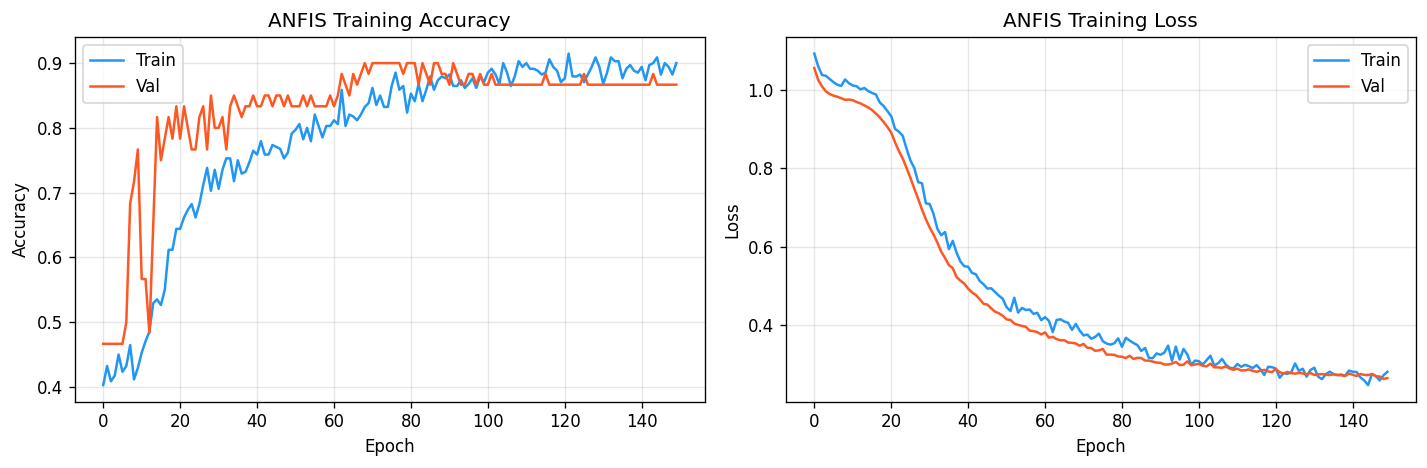

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train', color='#2196F3')
ax1.plot(history.history['val_accuracy'], label='Val',   color='#FF5722')
ax1.set_title('ANFIS Training Accuracy'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train', color='#2196F3')
ax2.plot(history.history['val_loss'], label='Val',   color='#FF5722')
ax2.set_title('ANFIS Training Loss'); ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight'); plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step
Classification Report:
              precision    recall  f1-score   support

        Poor       0.82      0.93      0.88        15
     Average       0.95      0.84      0.89        43
        Good       0.91      0.98      0.94        42

    accuracy                           0.91       100
   macro avg       0.89      0.92      0.90       100
weighted avg       0.91      0.91      0.91       100



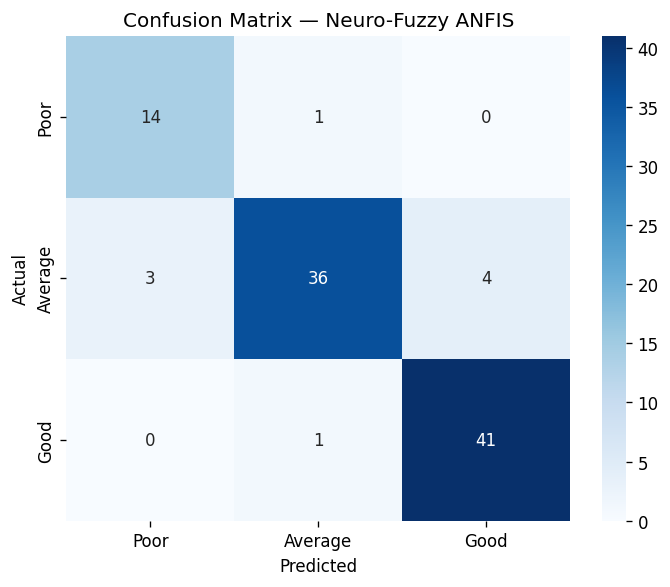

In [10]:
y_pred = np.argmax(model.predict(X_test_f), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Confusion Matrix — Neuro-Fuzzy ANFIS')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight'); plt.show()

In [11]:
def predict_student(attendance, assignment, test):
    """Hybrid prediction: fuzzy rule + neural network."""
    raw = np.array([[attendance, assignment, test]], dtype=float)
    fuzzy_feat = build_fuzzy_features(raw)

    # Fuzzy rule prediction
    fuzzy_class = fuzzy_infer(attendance, assignment, test)

    # Neural network prediction
    probs = model.predict(fuzzy_feat, verbose=0)[0]
    nn_class = np.argmax(probs)

    # Ensemble: average probabilities
    fuzzy_probs = np.zeros(3); fuzzy_probs[fuzzy_class] = 1.0
    final_probs = 0.4 * fuzzy_probs + 0.6 * probs
    final_class = np.argmax(final_probs)

    print(f"Student: Attendance={attendance}, Assignment={assignment}, Test={test}")
    print(f"  Fuzzy rule prediction  : {labels[fuzzy_class]}")
    print(f"  Neural net prediction  : {labels[nn_class]} ({probs.max():.1%})")
    print(f"  ▶ Hybrid (ensemble)    : {labels[final_class]} "
          f"(Poor={final_probs[0]:.2f}, Avg={final_probs[1]:.2f}, Good={final_probs[2]:.2f})")
    return labels[final_class]

# Test cases
predict_student(72, 65, 58)
print()
predict_student(45, 38, 30)
print()
predict_student(92, 88, 95)

Student: Attendance=72, Assignment=65, Test=58
  Fuzzy rule prediction  : Good
  Neural net prediction  : Average (89.7%)
  ▶ Hybrid (ensemble)    : Average (Poor=0.00, Avg=0.54, Good=0.46)

Student: Attendance=45, Assignment=38, Test=30
  Fuzzy rule prediction  : Poor
  Neural net prediction  : Poor (80.3%)
  ▶ Hybrid (ensemble)    : Poor (Poor=0.88, Avg=0.12, Good=0.00)

Student: Attendance=92, Assignment=88, Test=95
  Fuzzy rule prediction  : Good
  Neural net prediction  : Good (98.9%)
  ▶ Hybrid (ensemble)    : Good (Poor=0.00, Avg=0.01, Good=0.99)


'Good'